In [27]:
import pickle
import numpy as np
import pandas as pd
import os
from iblatlas.atlas import BrainRegions
from datetime import datetime

from one.api import ONE
one= ONE()

In [28]:
prefix = '/home/ines/repositories/'
# prefix = '/Users/ineslaranjeira/Documents/Repositories/'

# Load data

In [29]:
import brainwidemap
# this dataframe holds a summary of all the sessions
# and for us importantly, the eids and pids
bwm_df = brainwidemap.bwm_query()  # each row of this dataframe is a recording

n_sessions = bwm_df["eid"].unique().shape[0]
n_insertions = bwm_df["pid"].unique().shape[0]
print(
    f"{n_sessions} sessions with {n_insertions} individual neuropixel recordings"
)
# bwm_df.head()
bwm_pid = bwm_df['pid'].unique()

Loading bwm_query results from fixtures/2023_12_bwm_release.csv
459 sessions with 699 individual neuropixel recordings


## LDA axis

In [30]:
# cluster_df = pd.read_pickle(data_path+'extended_mouse_LDA_5_bins_cut')
data_path = prefix + 'representation_learning_variability/paper-individuality/clustering/'
# session_cluster = pd.read_parquet(data_path+'cluster_per_session')
lda = pd.read_pickle(data_path+'mouse_LDA_5_bins_cut06-07-2026')
lda = lda.rename(columns={0: 'lda_1'})

lda_eid = lda.loc[lda['session'].isin(list(bwm_df.eid)), 'session']
lda_pid = bwm_df.loc[bwm_df['eid'].isin(lda_eid), 'pid']

In [31]:
print(len(lda_eid))
print(len(lda_pid))

244
380


## Available neural files

In [32]:
save_states_path = prefix + 'representation_learning_variability/paper-individuality/data/neuron_files/'
# save_states_path = '/Users/ineslaranjeira/Google Drive/O meu disco/CCU/PhD Project/paper-individuality/data/neuron_files/'

filepaths = [os.path.join(save_states_path, filename) for filename in os.listdir(save_states_path)]
print(len(filepaths))

380


# Encoding model (Musall-adapted)

Fit a per-neuron linear encoding model on a single session and partition explained
variance into **task** vs **motor (states)** using cross-validated unique ΔR².
Regressor construction lives in `encoding_functions.py`.

In [33]:
# Initialize IBL Brain Atlas and target regions
BRAIN_REGIONS = ['VISa', 'VISam', 'CA1', 'DG', 'LP', 'PO']
regions = BrainRegions()

def get_simplified_area(col_name, filter_sessions=False):
    """Traces an Allen ID/acronym back up to our 6 target regions."""
    raw_acronym = col_name.split('_neuron_')[0]
    allen_ids = regions.acronym2id(raw_acronym)
    beryl_ids = regions.remap(allen_ids, source_map='Allen', target_map='Beryl')
    ancestor = regions.id2acronym(beryl_ids)[0]
    if filter_sessions:
        if ancestor in BRAIN_REGIONS:
            return ancestor
        else:
            return None
    else:
        return ancestor

In [34]:
relevant_pids = lda_pid.copy()

In [35]:
# =========================================================================
# Musall-adapted encoding model  (logic lives in encoding_functions.py)
# -------------------------------------------------------------------------
# Timings are derived from the neuron file itself (no ONE call needed):
#   stimOn ~= goCueTrigger_times ; feedback = goCue + response ; firstMove = goCue + reaction
# (derived vs canonical ONE times fall in the same 16.67 ms bin >=99.9% of trials).
#
# Regressors follow Musall et al. 2019, split into THREE GROUPS for the dR2 partition:
#   TASK             : stimOn, feedback correct/error, choice (aligned to firstMove),
#                      prior(block), signed contrast   [raised-cosine event kernels]
#   MOTOR_STATES     : paw / whisk / lick discrete HMM states (one-hot)
#   MOTOR_CONTINUOUS : L/R paw speed (log1p), whisker motion-energy, lick count (log1p)
#
# LAGGING (Musall-faithful): event-type variables get time-shifted copies; ANALOG
# variables do NOT ("we did not use any lagged versions of analog variables").
#   -> task events: lagged (event kernels).
#   -> motor STATES = Musall's "motor events (licking/whisking)": lagged (+/-150 ms).
#   -> motor CONTINUOUS = analog signals: NOT lagged.
# Set motor_lags=True to lag both groups (fairer states-vs-continuous, but deviates
# from the paper); motor_lags=('motor_states',) is the paper-faithful default.
# NaNs (tracking gaps, unknown states) are NOT interpolated: those bins are dropped.
# =========================================================================
import importlib
import encoding_functions as ef
importlib.reload(ef)

# --- pick one session that has a neuron file ---
available_pids = {os.path.basename(fp).replace('states_neurons_file_', '') for fp in filepaths}
pid = next(p for p in relevant_pids if p in available_pids)

filepath = os.path.join(save_states_path, f'states_neurons_file_{pid}')
with open(filepath, 'rb') as f:
    session_df = pickle.load(f)
print('session:', session_df['session'].iloc[0], '| pid:', pid)

# --- build the design matrix (paper-faithful lagging) ---
X, groups, trial_ids, keep = ef.build_design_matrix(session_df, motor_lags=('motor_states',))
print(f'design matrix: {X.shape[0]} bins x {X.shape[1]} regressors '
      f'({keep.mean()*100:.0f}% of bins kept after dropping NaN/tracking-gap bins)')
for g, cols in groups.items():
    print(f'  {g:17s}: {len(cols)} cols')

session: 77e6dc6a-66ed-433c-b1a2-778c914f523c | pid: 7b05cccc-44f6-4491-a0ea-e38d6e95513d
design matrix: 111433 bins x 86 regressors (52% of bins kept after dropping NaN/tracking-gap bins)
  task             : 42 cols
  motor_states     : 40 cols
  motor_continuous : 4 cols


In [36]:
# --- response matrix: all neurons in this session ---
spike_cols = [c for c in session_df.columns if c.endswith('_spike_count')]
Y = session_df.loc[keep, spike_cols].values.astype(float)
print(f'{len(spike_cols)} neurons')

# --- fit full ridge model (grouped CV) + variance partition across the 3 groups ---
# dR2_<group> = cvR2(full) - cvR2(full without that group) = variance UNIQUE to it
results = ef.fit_and_partition(X, Y, groups, trial_ids)
results.insert(0, 'neuron', spike_cols)
results.insert(1, 'area', [c.split('_neuron_')[0] for c in spike_cols])
results.insert(2, 'pid', pid)

dR2_cols = [c for c in results.columns if c.startswith('dR2_')]
print(f'best ridge alpha = {results.attrs["best_alpha"]:.3g}')
print(f'mean cvR2 = {results["cv_r2"].mean():.3f}')
for c in dR2_cols:
    print(f'  mean {c} = {results[c].mean():.4f}')
results.head()

118 neurons
best ridge alpha = 1e+04
mean cvR2 = 0.016
  mean dR2_task = 0.0046
  mean dR2_motor_states = 0.0035
  mean dR2_motor_continuous = 0.0010


,neuron,area,pid,cv_r2,dR2_task,r2_task_only,dR2_motor_states,r2_motor_states_only,dR2_motor_continuous,r2_motor_continuous_only
0,PIR_neuron_39_spike_count,PIR,7b05cccc-44f6-4491-a0ea-e38d6e95513d,0.009571,0.001617,0.000282,0.009102,0.007291,0.000735,-0.000576
1,PIR_neuron_63_spike_count,PIR,7b05cccc-44f6-4491-a0ea-e38d6e95513d,0.001176,-0.000289,0.000080,0.000568,0.001487,-0.000022,0.000845
2,PIR_neuron_67_spike_count,PIR,7b05cccc-44f6-4491-a0ea-e38d6e95513d,0.005291,0.001855,0.001912,0.002696,0.003003,0.000563,0.000003
3,PIR_neuron_70_spike_count,PIR,7b05cccc-44f6-4491-a0ea-e38d6e95513d,0.000951,-0.000416,-0.000323,0.000825,0.001351,0.000015,0.000531
4,PIR_neuron_73_spike_count,PIR,7b05cccc-44f6-4491-a0ea-e38d6e95513d,0.018767,0.004081,0.005289,0.002717,0.013014,0.001545,0.011690


In [37]:
# --- significance: circular-shift null for each group's unique dR2 ---
# Each neuron's spikes are circularly shifted (keeps autocorrelation, breaks
# alignment to regressors) and dR2 is recomputed. ~2 min for 50 shuffles;
# raise n_shuffles for tighter p-values.
obs, pvals, null = ef.shuffle_null(X, Y, groups, trial_ids,
                                   results.attrs['best_alpha'], n_shuffles=50)
for g in obs:
    results[f'p_{g}'] = pvals[g]
    print(f'{g:17s}: {(pvals[g] < 0.05).mean()*100:4.0f}% of neurons '
          f'with dR2 above chance (p<0.05)')

KeyboardInterrupt: 

In [ ]:
# Per-area summary (means across neurons)
summary_cols = ['cv_r2'] + dR2_cols
area_summary = (results.groupby('area')[summary_cols]
                .mean().sort_values('cv_r2', ascending=False))
area_summary['n_neurons'] = results.groupby('area').size()
area_summary.round(4)

,cv_r2,dR2_task,dR2_motor_states,dR2_motor_continuous,n_neurons
area,,,,,
CLA,0.0549,0.0338,0.0021,0.0016,8
AId6b,0.0459,0.0073,0.0169,0.0019,3
MOp6b,0.0273,0.0017,0.0131,0.0165,1
AIv6a,0.0239,0.0084,0.0074,0.0010,3
MOp6a,0.0230,0.0043,0.0048,0.0019,21
AIv5,0.0186,0.0041,0.0027,0.0012,12
PIR,0.0076,0.0013,0.0030,0.0004,23
OLF,0.0070,0.0011,0.0030,0.0005,29
scwm,0.0063,0.0011,0.0025,0.0003,4


/tmp/ipykernel_58621/74529069.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=results, x='area', y='cv_r2', order=order, ax=ax, palette='Set2')


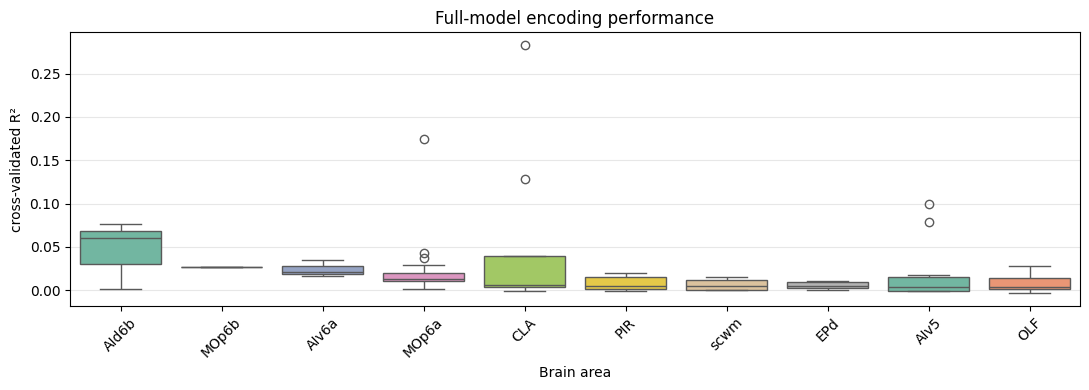

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Full-model encoding performance per area
order = results.groupby('area')['cv_r2'].median().sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(11, 4))
sns.boxplot(data=results, x='area', y='cv_r2', order=order, ax=ax, palette='Set2')
ax.set(xlabel='Brain area', ylabel='cross-validated R²',
       title='Full-model encoding performance')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=.3)
plt.tight_layout()
plt.show()

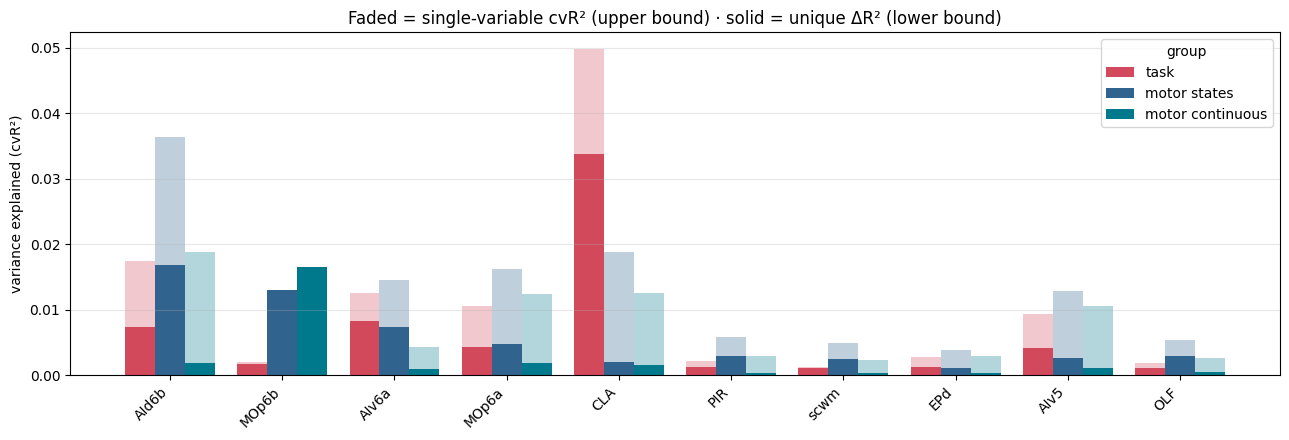

In [ ]:
# 2) THE KEY COMPARISON (as in Musall Fig. 4): for each variable group show BOTH
#    the single-variable model cvR² (upper bound = total explanatory power, faded)
#    and the unique ΔR² (lower bound = variance only that group explains, solid).
groups_plot = ['task', 'motor_states', 'motor_continuous']
labels = {'task': 'task', 'motor_states': 'motor states',
          'motor_continuous': 'motor continuous'}
colors = {'task': '#d1495b', 'motor_states': '#30638e',
          'motor_continuous': '#00798c'}
only = results.groupby('area')[[f'r2_{g}_only' for g in groups_plot]].mean().loc[order]
uniq = results.groupby('area')[[f'dR2_{g}' for g in groups_plot]].mean().loc[order]

x = np.arange(len(order))
w = 0.8 / len(groups_plot)
fig, ax = plt.subplots(figsize=(13, 4.5))
for i, g in enumerate(groups_plot):
    pos = x + (i - (len(groups_plot) - 1) / 2) * w
    ax.bar(pos, only[f'r2_{g}_only'], w, color=colors[g], alpha=.30)
    ax.bar(pos, uniq[f'dR2_{g}'], w, color=colors[g], label=labels[g])
ax.set_xticks(x)
ax.set_xticklabels(order, rotation=45, ha='right')
ax.set(ylabel='variance explained (cvR²)',
       title='Faded = single-variable cvR² (upper bound) · '
             'solid = unique ΔR² (lower bound)')
ax.legend(title='group')
ax.grid(axis='y', alpha=.3)
plt.tight_layout()
plt.show()

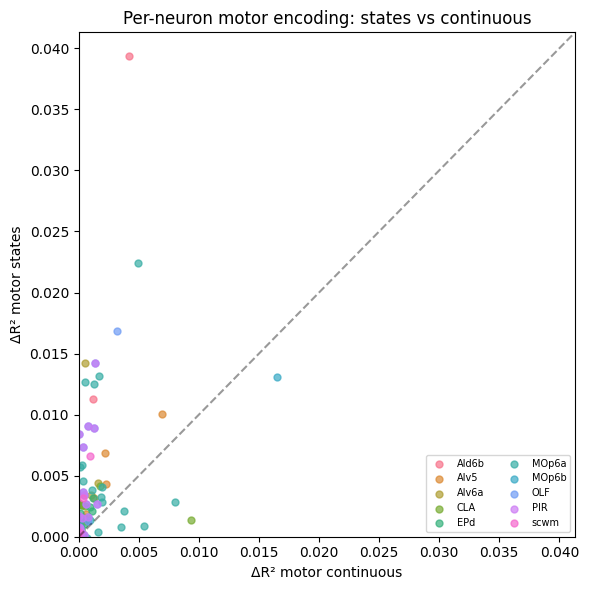

In [ ]:
# 3) Per-neuron motor encoding: discrete STATES vs CONTINUOUS signals
#    (the comparison to build on later). Above the diagonal = states capture more.
fig, ax = plt.subplots(figsize=(6, 6))
areas = sorted(results['area'].unique())
pal = dict(zip(areas, sns.color_palette('husl', len(areas))))
for a in areas:
    sub = results[results['area'] == a]
    ax.scatter(sub['dR2_motor_continuous'], sub['dR2_motor_states'],
               s=25, alpha=.7, color=pal[a], label=a)
lim = max(results['dR2_motor_states'].max(),
          results['dR2_motor_continuous'].max()) * 1.05
ax.plot([0, lim], [0, lim], 'k--', alpha=.4)
ax.set(xlabel='ΔR² motor continuous', ylabel='ΔR² motor states',
       title='Per-neuron motor encoding: states vs continuous',
       xlim=(0, lim), ylim=(0, lim))
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

## Model interpretation: predictions & coefficients

In [ ]:
# Coefficients (fit on all data) + held-out CV predictions, at the chosen alpha
alpha = results.attrs['best_alpha']
W, colnames, ymu = ef.fit_coefficients(X, Y, alpha)     # W: (n_regressors, n_neurons)
Ypred_cv = ef.cv_predictions(X, Y, trial_ids, alpha)    # held-out predictions

# pick a well-predicted example neuron
j = int(np.nanargmax(results['cv_r2'].values))
print(f"example neuron: {results['neuron'].iloc[j]} ({results['area'].iloc[j]}), "
      f"cvR² = {results['cv_r2'].iloc[j]:.3f}")

example neuron: CLA_neuron_323_spike_count (CLA), cvR² = 0.283


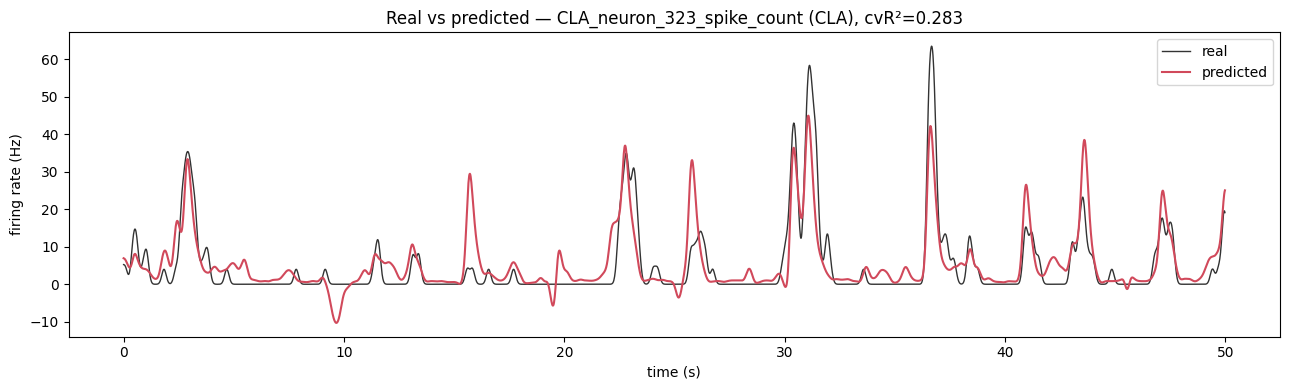

In [ ]:
# 4) Real vs predicted activity (held-out) for the example neuron.
# Raw 60 Hz spike counts are noisy, so lightly Gaussian-smooth (~100 ms) for display.
from scipy.ndimage import gaussian_filter1d

sigma = 6  # bins (~100 ms)
yt = gaussian_filter1d(Y[:, j], sigma) * ef.FS          # -> Hz
yp = gaussian_filter1d(Ypred_cv[:, j], sigma) * ef.FS
seg = slice(0, min(3000, len(yt)))                      # first ~50 s
tt = np.arange(len(yt))[seg] / ef.FS

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(tt, yt[seg], label='real', color='k', alpha=.8, lw=1)
ax.plot(tt, yp[seg], label='predicted', color='#d1495b', lw=1.5)
ax.set(xlabel='time (s)', ylabel='firing rate (Hz)',
       title=f"Real vs predicted — {results['neuron'].iloc[j]} "
             f"({results['area'].iloc[j]}), cvR²={results['cv_r2'].iloc[j]:.3f}")
ax.legend()
plt.tight_layout()
plt.show()

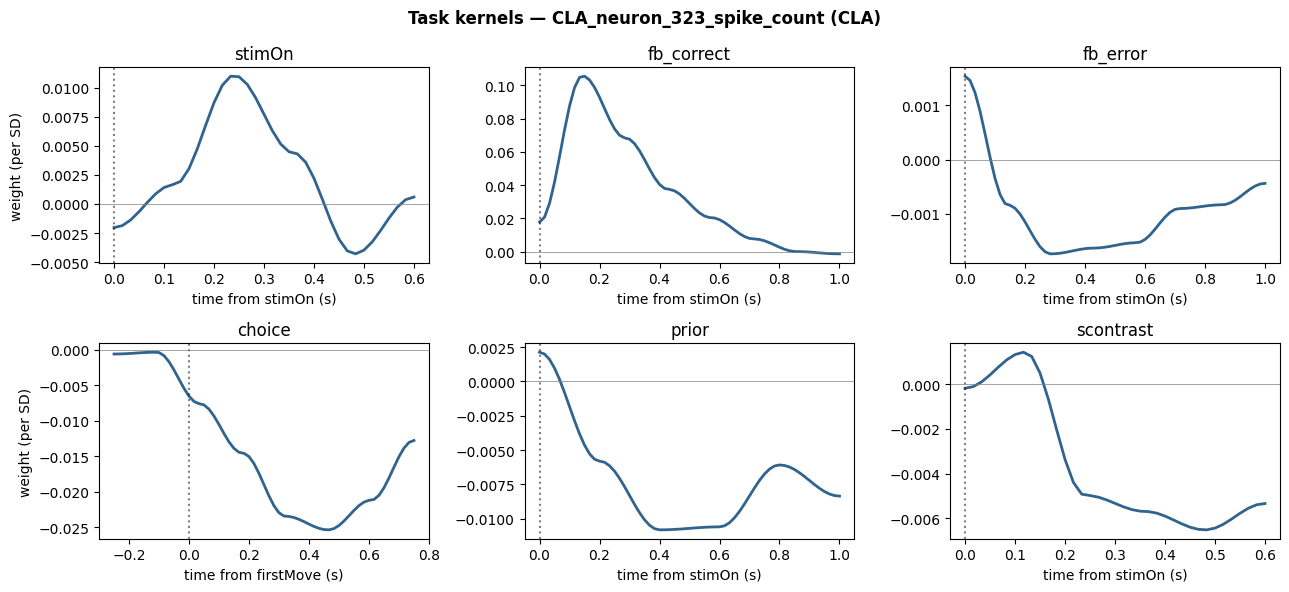

In [ ]:
# 5) TASK kernels: reconstructed temporal weight of each task regressor (example neuron)
task_events = ['stimOn', 'fb_correct', 'fb_error', 'choice', 'prior', 'scontrast']
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, ev in zip(axes.flat, task_events):
    t, k = ef.event_kernel(ev, W[:, j], colnames)
    ax.plot(t, k, color='#30638e', lw=2)
    ax.axvline(0, color='k', ls=':', alpha=.5)
    ax.axhline(0, color='grey', lw=.5)
    align = 'firstMove' if ev == 'choice' else 'stimOn'
    ax.set(title=ev, xlabel=f'time from {align} (s)')
axes[0, 0].set_ylabel('weight (per SD)')
axes[1, 0].set_ylabel('weight (per SD)')
fig.suptitle(f"Task kernels — {results['neuron'].iloc[j]} ({results['area'].iloc[j]})",
             fontweight='bold')
plt.tight_layout()
plt.show()

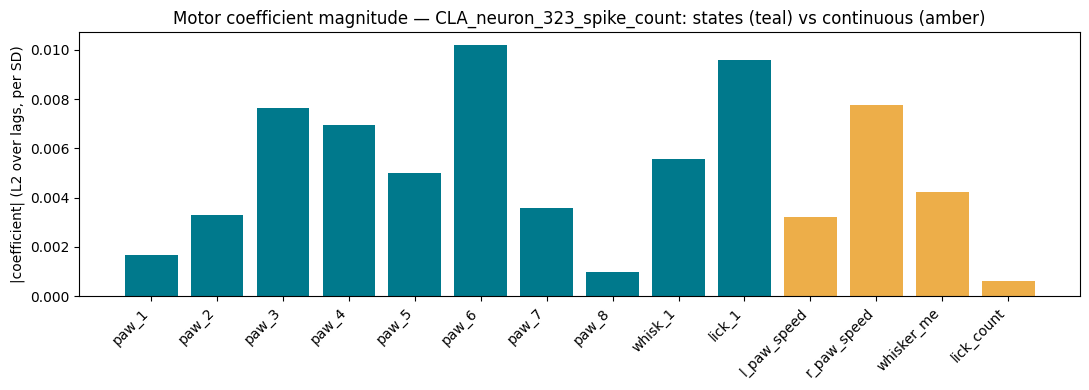

In [ ]:
# 6) MOTOR coefficients: per base-signal magnitude (L2 over its lag basis) for the
#    example neuron. states (teal) vs continuous (amber).
def base_name(col):
    return col.rsplit('_L', 1)[0]          # strip the lag-basis suffix

motor_mag = {}
motor_kind = {}
for grp, kind in [('motor_states', 'state'), ('motor_continuous', 'continuous')]:
    for col in groups[grp]:
        b = base_name(col)
        motor_mag.setdefault(b, 0.0)
        motor_mag[b] += W[colnames.index(col), j] ** 2
        motor_kind[b] = kind
bases = list(motor_mag)
mags = [np.sqrt(motor_mag[b]) for b in bases]
bar_colors = ['#00798c' if motor_kind[b] == 'state' else '#edae49' for b in bases]

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(range(len(bases)), mags, color=bar_colors)
ax.set_xticks(range(len(bases)))
ax.set_xticklabels(bases, rotation=45, ha='right')
ax.set(ylabel='|coefficient| (L2 over lags, per SD)',
       title=f"Motor coefficient magnitude — {results['neuron'].iloc[j]}: "
             f"states (teal) vs continuous (amber)")
plt.tight_layout()
plt.show()

## Scale to multiple sessions

Run the per-session pipeline over many sessions, caching one parquet per session
(resumable — rerun to add more). Then aggregate task vs motor-states vs
motor-continuous across areas/sessions.

In [38]:
# Scale the ENCODING model across sessions, STATES-ONLY (task + motor states):
# drops motor_continuous to avoid task/motor collinearity and paw tracking-gap bin loss.
# Per-session parquet cache -> resumable; raise N_SESSIONS to scale up.
# Results keep `session` (eid) + `mouse_name` so LDA1 can be merged on later.
N_SESSIONS = 380            # testing; raise to scale up
N_SHUFFLES = 0           # per-session null; set 0 to skip while scaling fast
results_dir = 'encoding_results'
os.makedirs(results_dir, exist_ok=True)

pids_to_run = [p for p in relevant_pids if p in available_pids][:N_SESSIONS]
all_res = []
for k, pid_k in enumerate(pids_to_run):
    cache = os.path.join(results_dir, f'{pid_k}.parquet')
    if os.path.exists(cache):
        all_res.append(pd.read_parquet(cache))
        continue
    try:
        with open(os.path.join(save_states_path, f'states_neurons_file_{pid_k}'), 'rb') as f:
            df_k = pickle.load(f)
        # r_k = ef.fit_session(df_k, motor_continuous=False, motor_lags=('motor_states',),
        #                      n_shuffles=N_SHUFFLES)
        r_k = ef.fit_session(df_k, motor_continuous=False, motor_lags=(),
                             n_shuffles=N_SHUFFLES)
        r_k['pid'] = pid_k
        r_k['session'] = df_k['session'].iloc[0]
        r_k['mouse_name'] = df_k['mouse_name'].iloc[0]   # for later mouse-clustered LDA1 analysis
        r_k.to_parquet(cache)
        all_res.append(r_k)
        print(f'[{k+1}/{len(pids_to_run)}] {pid_k[:8]}: {len(r_k)} neurons, '
              f'mean cvR²={r_k["cv_r2"].mean():.3f}, {r_k["frac_bins_kept"].iloc[0]*100:.0f}% bins')
    except Exception as e:
        print(f'[{k+1}/{len(pids_to_run)}] {pid_k[:8]} FAILED: {type(e).__name__}: {e}')

pop = pd.concat(all_res, ignore_index=True)
print(f'\ntotal: {len(pop)} neurons from {pop["pid"].nunique()} session(s)')


total: 65374 neurons from 380 session(s)


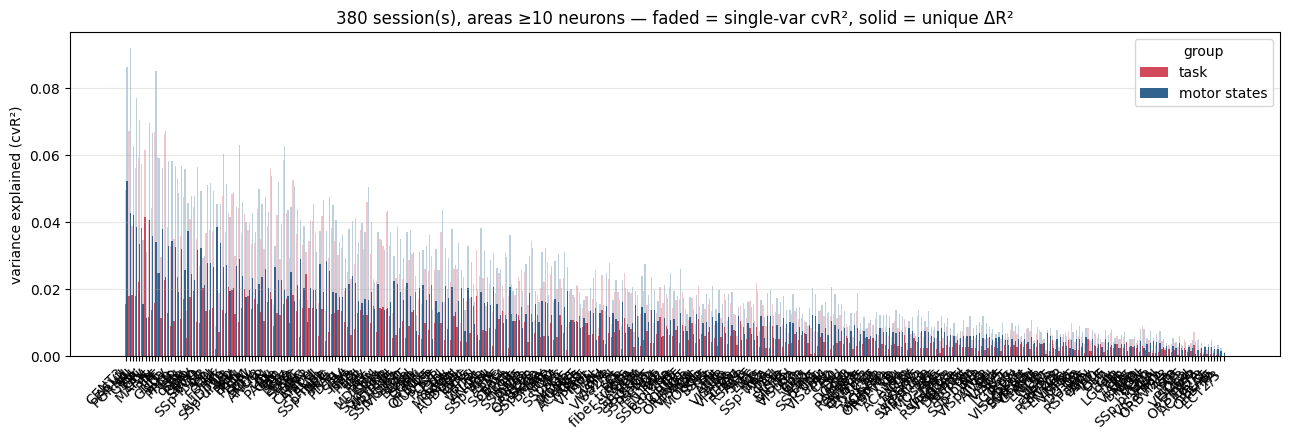

In [40]:
# Aggregate across sessions: single-variable cvR² (faded) + unique ΔR² (solid) per
# group per area (areas with >=10 neurons). Adapts to whichever groups are present.
counts = pop.groupby('area').size()
keep_areas = counts[counts >= 10].index
sub = pop[pop['area'].isin(keep_areas)]
gp = [g for g in ['task', 'motor_states', 'motor_continuous']
      if f'dR2_{g}' in pop.columns]
labels = {'task': 'task', 'motor_states': 'motor states', 'motor_continuous': 'motor continuous'}
colors = {'task': '#d1495b', 'motor_states': '#30638e', 'motor_continuous': '#00798c'}

uniq = sub.groupby('area')[[f'dR2_{g}' for g in gp]].mean()
only = sub.groupby('area')[[f'r2_{g}_only' for g in gp]].mean()
order_a = uniq.sum(1).sort_values(ascending=False).index
uniq, only = uniq.loc[order_a], only.loc[order_a]

x = np.arange(len(order_a))
w = 0.8 / len(gp)
fig, ax = plt.subplots(figsize=(13, 4.5))
for i, g in enumerate(gp):
    pos = x + (i - (len(gp) - 1) / 2) * w
    ax.bar(pos, only[f'r2_{g}_only'], w, color=colors[g], alpha=.30)
    ax.bar(pos, uniq[f'dR2_{g}'], w, color=colors[g], label=labels[g])
ax.set_xticks(x)
ax.set_xticklabels(order_a, rotation=45, ha='right')
ax.set(ylabel='variance explained (cvR²)',
       title=f'{pop["pid"].nunique()} session(s), areas ≥10 neurons — '
             f'faded = single-var cvR², solid = unique ΔR²')
ax.legend(title='group')
ax.grid(axis='y', alpha=.3)
plt.tight_layout()
plt.show()

In [41]:
# Per-area summary table: mean ΔR² and fraction of neurons above chance (p<0.05).
agg_spec = {'n': ('cv_r2', 'size'), 'cvR2': ('cv_r2', 'mean')}
for g in gp:
    agg_spec[f'dR2_{g}'] = (f'dR2_{g}', 'mean')
    if f'p_{g}' in sub.columns:
        agg_spec[f'sig_{g}'] = (f'p_{g}', lambda s: (s < 0.05).mean())
summary = sub.groupby('area').agg(**agg_spec).sort_values('cvR2', ascending=False)
summary.round(3)

,n,cvR2,dR2_task,sig_task,dR2_motor_states,sig_motor_states
area,,,,,,
ACVII,17,0.110,0.018,0.0,0.043,0.0
CENT3,381,0.102,0.016,0.0,0.052,0.0
I5,14,0.101,0.016,0.0,0.034,0.0
VII,39,0.095,0.018,0.0,0.039,0.0
GRN,299,0.093,0.022,0.0,0.034,0.0
...,...,...,...,...,...,...
BLAp,49,0.004,0.001,0.0,0.002,0.0
HATA,20,0.004,0.001,0.0,0.003,0.0
ORBm5,14,0.004,0.000,0.0,0.002,0.0


## Effect of LDA1 on encoding

Does LDA1 (one value per session) predict total encoding (cvR²) and the task-vs-motor
split? Tested with the **same framework as the firing-rate / fano-factor / noise-correlation
notebooks**: Frisch–Waugh–Lovell residualization on brain region + `n_bins`, then a
**session-stratified permutation test** (shuffle LDA1 across sessions → respects
neuron-within-session pseudoreplication) and a **partial-correlation JZS Bayes factor**
(`pingouin.bayesfactor_pearson`, Wetzels & Wagenmakers 2012).

**Caveat:** the BF's effective N is the neuron count, so it ignores clustering and can read
"strong H1" on a tiny partial r — trust **`p_perm`** for significance. (A mouse-level shuffle
`perm_group='mouse_name'` is available as an extra check, but session is the primary level here.)
Scale up the sweep for power.

In [ ]:
# LDA1 effect: session-stratified permutation test + partial-correlation JZS Bayes
# factor (same framework as fano_factor / firing_rate / noise_correlations).
# Covariates: brain region C(area) + n_bins (data amount, analogous to the paper's n_trials).
importlib.reload(ef)
import glob
pop_all = pd.concat([pd.read_parquet(f)
                     for f in glob.glob(os.path.join(results_dir, '*.parquet'))],
                    ignore_index=True)
# pop_all = pop_all.loc[pop_all['area']=='CA1']
print(f'{len(pop_all)} neurons | {pop_all["pid"].nunique()} sessions | '
      f'{pop_all["mouse_name"].nunique()} mice\n')

# task_fraction = dR2_task / (dR2_task + dR2_motor_states) -> relative task contribution
lda_targets = ['cv_r2', 'dR2_task', 'dR2_motor_states']  #, 'task_fraction'
lda_targets = ['cv_r2', 'r2_task_only', 'r2_motor_states_only']  #, 'task_fraction'

lda_stats = pd.DataFrame([ef.lda1_perm_bf(pop_all, lda, target=t, perm_group='session', n_perm=2000)
                          for t in lda_targets]).dropna(how='all')
# (rerun any row with perm_group='mouse_name' if you want the conservative check)
lda_stats[['target', 'n', 'n_groups', 'slope', 'r_partial', 'bf10', 'bf_evidence', 'p_perm']].round(4)

883 neurons | 76 sessions | 43 mice

[cv_r2         ] slope=+0.0001576  r_partial=+0.025  BF10=0.0559 (strong H0)  p_perm=0.6790  | 883 neurons, 67 sessions
[r2_task_only  ] slope=-4.489e-05  r_partial=-0.011  BF10=0.0445 (strong H0)  p_perm=0.8725  | 883 neurons, 67 sessions
[r2_motor_states_only] slope=+0.000276  r_partial=+0.051  BF10=0.135 (moderate H0)  p_perm=0.4090  | 883 neurons, 67 sessions


,target,n,n_groups,slope,r_partial,bf10,bf_evidence,p_perm
0,cv_r2,883,67,0.0002,0.0253,0.0559,strong H0,0.6790
1,r2_task_only,883,67,-0.0000,-0.0111,0.0445,strong H0,0.8725
2,r2_motor_states_only,883,67,0.0003,0.0514,0.1350,moderate H0,0.4090


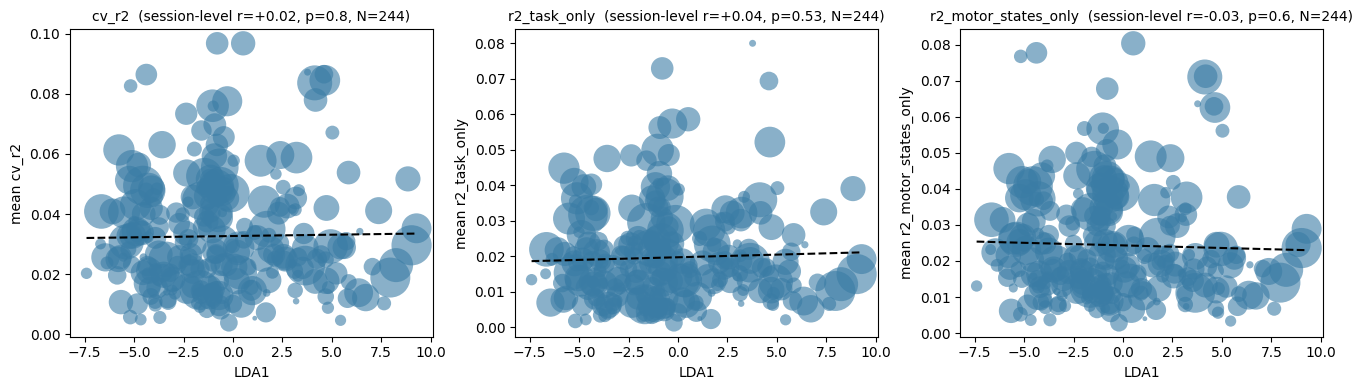

In [50]:
# Descriptive session-level scatter vs LDA1 (LDA1 is per session; stats = mixed model above)
fig, axes = plt.subplots(1, len(lda_targets), figsize=(4.5 * len(lda_targets), 4))
for ax, t in zip(np.atleast_1d(axes), lda_targets):
    ef.plot_lda1_effect(pop_all, lda, target=t, ax=ax)
plt.tight_layout()
plt.show()